# ML-04 — Search Intelligence Data Contract

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w03_data_contract.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Unit of analysis + time window

*One row = one what, over which dates? State it, then verify it below.*

For a analyzing this dataset **one row** could be:

A single row represents a unique **content's** search performance,content performance,engagement metrics over a specific period of time for a specific **client**
Regarding time window, I will primarily use the last 90 days of data while also using the last 30 days as recent historical features.

Following code verify my above statement by loading first 5 rows of the dataset, it's info(total columns and their datatypes).

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


In [3]:
#Setup of Dataet to work on
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

# The label: a page is 'declining' when its recent trend is down. Simple, honest starter label.
df["is_declining_label"] = df["trend_direction"].str.lower().eq("down").astype(int)
print(df.shape[0], "pages |  declining rate:", round(df["is_declining_label"].mean(), 3))

30000 pages |  declining rate: 0.542


In [4]:
#Loading first five rows of dataset to know one row is equal to what
import pandas as pd


try:
    df_impressions_ctr = pd.read_csv('data/raw/content_refresh_anonymized.csv')
    print("Dataset loaded successfully.")
    print("\nFirst 5 rows of the dataset :")
    display(df_impressions_ctr.head())
    print("\nDataFrame Info (to understand columns and data types):")
    df_impressions_ctr.info()
except FileNotFoundError:
    print("Error: Dataetset not found.")
    print("Please upload your CSV file to the Colab environment or provide the correct path.")
except Exception as e:
    print(f"An error occurred while loading the data: {e}")


Dataset loaded successfully.

First 5 rows of the dataset :


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7



DataFrame Info (to understand columns and data types):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              30000 non-null  object 
 1   client_id               30000 non-null  object 
 2   search_volume           27532 non-null  float64
 3   competition             27532 non-null  float64
 4   competition_level       27390 non-null  object 
 5   cpc                     27532 non-null  float64
 6   content_type            30000 non-null  object 
 7   main_intent             27626 non-null  object 
 8   word_count              22301 non-null  float64
 9   char_count              22301 non-null  float64
 10  provider_used           8562 non-null   object 
 11  model_used              24267 non-null  object 
 12  impressions_90d         30000 non-null  int64  
 13  clicks_90d              30000 non-n

## 2. Fields: feature / label / context / excluded

*Sort every field you plan to touch into these four buckets. Excluded needs a why.*

In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


### Creating appropriate Label for my lane: 'High Impressions & Position-Tiered Low CTR'

Building on the previous approach, we will now define 'low CTR' relative to each `position_tier`. This means we'll calculate a distinct 'low CTR' threshold (e.g., 25th percentile) for every unique `position_tier` present in your data.

*   **High Impressions**: Still defined globally (e.g., above the 75th percentile of `impressions_90d`).
*   **Low CTR (Tiered)**: CTR below the 25th percentile *for that specific `position_tier`*.

We will create a new label, `is_high_impressions_low_ctr_tiered`, which will be `1` if a page meets the global high impressions threshold AND its CTR is below its respective `position_tier`'s low CTR threshold.

In [5]:
# Recalculate the global 75th percentile for impressions to define 'high impressions'
# This can remain global unless you also want to tier impressions.
high_impressions_threshold_global = df['impressions_90d'].quantile(0.75)

print(f"Global Threshold for High Impressions (75th percentile): {high_impressions_threshold_global:.2f}")

# Calculate the 25th percentile for CTR for EACH position_tier
# The .transform() method applies the quantile calculation within each group and broadcasts the result
# back to the original DataFrame's shape, aligning it with the 'ctr' column.
df['low_ctr_threshold_per_tier'] = df.groupby('position_tier')['ctr'].transform(lambda x: x.quantile(0.25))

print("\nLow CTR thresholds per Position Tier (25th percentile of CTR within each tier):")
# Display the unique thresholds for inspection
display(df[['position_tier', 'low_ctr_threshold_per_tier']].drop_duplicates().sort_values('position_tier'))

# Create the new, refined label: is_high_impressions_low_ctr_tiered
# This label will be 1 if a page has global high impressions AND its CTR is below its tier-specific low CTR threshold.
df['is_high_impressions_low_ctr_tiered'] = (
    (df['impressions_90d'] >= high_impressions_threshold_global) &
    (df['ctr'] <= df['low_ctr_threshold_per_tier'])
).astype(int)

# Display the count of pages meeting this new, refined criteria and the rate
num_high_impressions_low_ctr_tiered = df['is_high_impressions_low_ctr_tiered'].sum()
rate_high_impressions_low_ctr_tiered = df['is_high_impressions_low_ctr_tiered'].mean()

print(f"\nNumber of pages with High Impressions and Tiered Low CTR: {num_high_impressions_low_ctr_tiered}")
print(f"Rate of pages with High Impressions and Tiered Low CTR: {rate_high_impressions_low_ctr_tiered:.3f}")



Global Threshold for High Impressions (75th percentile): 3615.25

Low CTR thresholds per Position Tier (25th percentile of CTR within each tier):


,position_tier,low_ctr_threshold_per_tier
28,deep,0.0
3,page_1,0.0
1,page_3_5,0.0
0,striking,0.0
10,top_3,0.0



Number of pages with High Impressions and Tiered Low CTR: 146
Rate of pages with High Impressions and Tiered Low CTR: 0.005


### Updated Categorization of Fields for 'High Impressions & Position-Tiered Low CTR'

With our new label, `is_high_impressions_low_ctr_tiered`, the categorization of our columns changes slightly to avoid data leakage:

*   **Label**: `is_high_impressions_low_ctr_tiered`.
*   **Features**: All other relevant columns that help predict the label (i.e., characteristics of the content itself or its market context).
*   **Context**: `content_id`, `client_id` (identifiers).
*   **Excluded**: Columns that were directly used to create `is_high_impressions_low_ctr_tiered` or are directly or indirectly related with it are excluded to prevent data leakage.This includes:
    *   `impressions_90d` (used for high impressions threshold)
    *   `ctr` (used for low CTR threshold)
    *   `low_ctr_threshold_per_tier` (the intermediate calculation for the tiered CTR threshold)
    *   `position_tier` (used to define `low_ctr_threshold_per_tier`)
    *   `impression_tier` (binned version of `impressions_90d`)
    *   `avg_position` (a direct outcome of search performance, highly correlated with impressions/CTR)
    *   `trend_direction` (already excluded, as it derived the old label, and is still related).
    *   `trend_pct` (numerical basis for `trend_direction`, potential indirect leakage).
    *   `clicks_90d`, `pageviews_90d`, `sessions_90d` (direct components of CTR or highly correlated with impressions/CTR).
    *   `impressions_last_30d`, `clicks_last_30d`, `sessions_last_30d` (highly correlated with 90-day metrics, indicating recent performance).
    *   `impressions_prev_30d`, `clicks_prev_30d`, `sessions_prev_30d` (highly correlated with 90-day metrics, indicating prior performance).
    *   `users_90d`, `engaged_sessions_90d`, `ai_sessions_90d`, `scroll_events_90d` (other engagement metrics highly correlated with impressions/clicks).
    *   `days_with_impressions`, `days_with_sessions` (outcome metrics, correlated with impressions/sessions).
    *   `engagement_rate`, `scroll_rate`, `ai_traffic_pct` (derived engagement metrics, correlated with CTR/sessions).
    * `is_declining_label`

In [6]:
# Define the new label column
label_column = 'is_high_impressions_low_ctr_tiered'

# Context columns remain the same
context_columns = ['content_id', 'client_id']

# Exclude columns that directly derive the new label to prevent data leakage,
# are highly correlated with the label's components, or represent outcomes rather than predictors.
excluded_columns = [
    'trend_direction',
    'trend_pct',                   # Numerical basis for trend_direction; potential indirect leakage
    'impressions_90d',             # Directly used to calculate the new label
    'clicks_90d',                  # Direct component of CTR (used in label) and highly correlated with impressions
    'pageviews_90d',               # Highly correlated with clicks/sessions, post-impression outcome
    'sessions_90d',                # Highly correlated with clicks, post-impression outcome
    'impressions_last_30d',        # Highly correlated with impressions_90d
    'clicks_last_30d',             # Highly correlated with clicks_90d
    'sessions_last_30d',           # Highly correlated with sessions_90d
    'impressions_prev_30d',        # Highly correlated with impressions_90d
    'clicks_prev_30d',             # Highly correlated with clicks_90d
    'sessions_prev_30d',           # Highly correlated with sessions_90d
    'ctr',                         # Directly used to calculate the new label
    'low_ctr_threshold_per_tier',  # Intermediate column created for the new label
    'position_tier',               # Directly used in the calculation of low_ctr_threshold_per_tier
    'impression_tier',             # Binned version of impressions_90d
    'avg_position',                # Direct outcome of search performance; highly correlated
    'users_90d',                   # Outcome metric, highly correlated with impressions/sessions
    'engaged_sessions_90d',        # Outcome metric, highly correlated with sessions
    'ai_sessions_90d',             # Outcome metric, correlated with sessions
    'scroll_events_90d',           # Outcome metric, correlated with engagement
    'days_with_impressions',       # Outcome metric, correlated with impressions
    'days_with_sessions',          # Outcome metric, correlated with sessions
    'engagement_rate',             # Derived engagement metric, correlated with CTR/sessions
    'scroll_rate',                 # Derived engagement metric, correlated with scroll events
    'ai_traffic_pct',              # Derived metric, correlated with sessions
    'is_declining_label'
]

# All columns in the DataFrame
all_columns = df.columns.tolist()

# Identify feature columns
feature_columns = [col for col in all_columns
                   if col != label_column
                   and col not in context_columns
                   and col not in excluded_columns]

print(f"\nNew Label Column: {label_column}")
print(f"\nContext Columns: {context_columns}")
print(f"\nExcluded Columns: {excluded_columns}")
print(f"\nFeature Columns ({len(feature_columns)}):\n{feature_columns}")

# Display data types of new feature columns for further review
print("\nData Types of Feature Columns:")
df[feature_columns].info()


New Label Column: is_high_impressions_low_ctr_tiered

Context Columns: ['content_id', 'client_id']

Excluded Columns: ['trend_direction', 'trend_pct', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'ctr', 'low_ctr_threshold_per_tier', 'position_tier', 'impression_tier', 'avg_position', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'is_declining_label']

Feature Columns (17):
['search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier']

Data Types of Feature Columns:
<class 'pandas.core.frame.Dat

## 3. Verify it with queries (grain, counts, missing values, windows)




*Every claim above gets a query cell here. A contract claim without a query next to it is a guess.*

In [ ]:
Following are the codes that support my previous cell's claims related to unit of analysis(grain),counts, missing values and time windows.

SyntaxError: unterminated string literal (detected at line 3) (4166071135.py, line 3)

In [7]:
#Verifying the timewindow for 90 days
[col for col in df.columns if "90d" in col]


['impressions_90d',
 'clicks_90d',
 'pageviews_90d',
 'sessions_90d',
 'users_90d',
 'engaged_sessions_90d',
 'ai_sessions_90d',
 'scroll_events_90d']

In [8]:
#Verifying the time window for 30 days
[col for col in df.columns if "30d" in col]

['impressions_last_30d',
 'clicks_last_30d',
 'sessions_last_30d',
 'impressions_prev_30d',
 'clicks_prev_30d',
 'sessions_prev_30d']

In [9]:
# 3.1 Verify Unit of Analysis (Grain)
# Claim: A single row represents a unique content's search and engagement performance for a specific client over a defined time window.
# Verification: Check for uniqueness of content_id + client_id combined.

duplicate_rows = df.duplicated(subset=['content_id', 'client_id']).sum()

if duplicate_rows == 0:
    print("Verification successful: Each row represents a unique combination of 'content_id' and 'client_id'.")
else:
    print(f"Warning: Found {duplicate_rows} duplicate rows based on 'content_id' and 'client_id'. Further investigation might be needed.")

print(f"Total unique (content_id, client_id) pairs: {df[['content_id', 'client_id']].drop_duplicates().shape[0]}")
print(f"Total rows in DataFrame: {df.shape[0]}")

Verification successful: Each row represents a unique combination of 'content_id' and 'client_id'.
Total unique (content_id, client_id) pairs: 30000
Total rows in DataFrame: 30000


In [10]:
# 3.2 Verify Label Distribution and Counts
# Claim: The new label 'is_high_impressions_low_ctr_tiered' has a certain distribution (e.g., 146 pages, 0.005 rate).
# Verification: Display the value counts and rate of the label.

print("\nDistribution of 'is_high_impressions_low_ctr_tiered' label:")
label_counts = df['is_high_impressions_low_ctr_tiered'].value_counts()
label_rates = df['is_high_impressions_low_ctr_tiered'].value_counts(normalize=True).map(lambda x: f'{x:.3f}')

print("Counts:\n", label_counts)
print("Rates:\n", label_rates)


Distribution of 'is_high_impressions_low_ctr_tiered' label:
Counts:
 is_high_impressions_low_ctr_tiered
0    29854
1      146
Name: count, dtype: int64
Rates:
 is_high_impressions_low_ctr_tiered
0    0.995
1    0.005
Name: proportion, dtype: object


In [11]:
# 3.3 Check for Missing Values in Feature Columns
# Claim: Understand the completeness of the data used for features.
# Verification: Display the count and percentage of missing values for each feature column.

print("\nMissing values in Feature Columns:")
missing_values = df[feature_columns].isnull().sum()
missing_percent = (df[feature_columns].isnull().sum() / len(df) * 100).round(2)

missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing %': missing_percent
})

missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing %', ascending=False)

if not missing_info.empty:
    display(missing_info)
else:
    print("No missing values found in the identified feature columns.")


Missing values in Feature Columns:


,Missing Count,Missing %
provider_used,21438,71.46
char_count,7699,25.66
word_count_tier,7699,25.66
char_count_tier,7699,25.66
word_count,7699,25.66
model_used,5733,19.11
competition_level,2610,8.70
competition,2468,8.23
search_volume,2468,8.23
cpc,2468,8.23


## 4. Data limits

*What can this data never tell you? Unbalanced history, GSC-only early rows, window overlaps.*

In [12]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


### Investigating 'Unbalanced History'

'Unbalanced history' means that the distribution of  data over time might not be uniform or representative. For example, if most of  content was created very recently, or very long ago, it could bias the model. We can investigate this by looking at the distribution of content age related features like `content_age_days` and `days_since_last_update`.

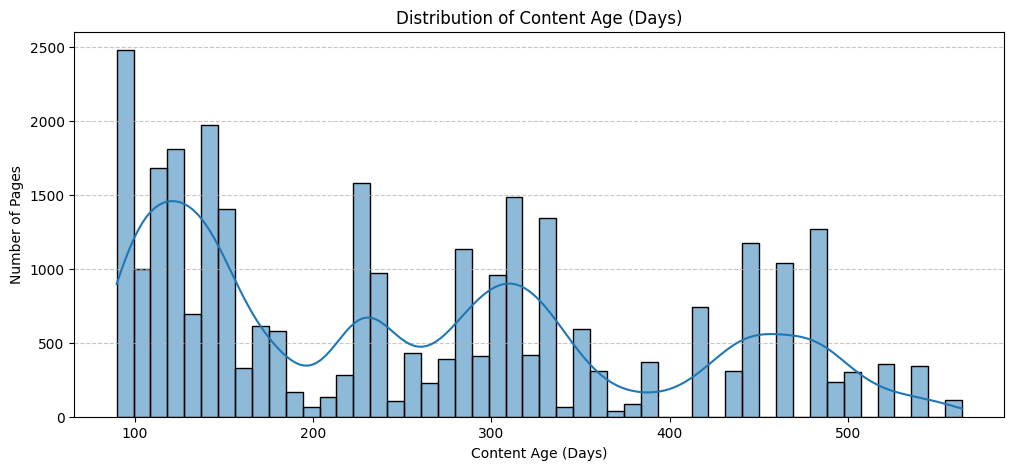

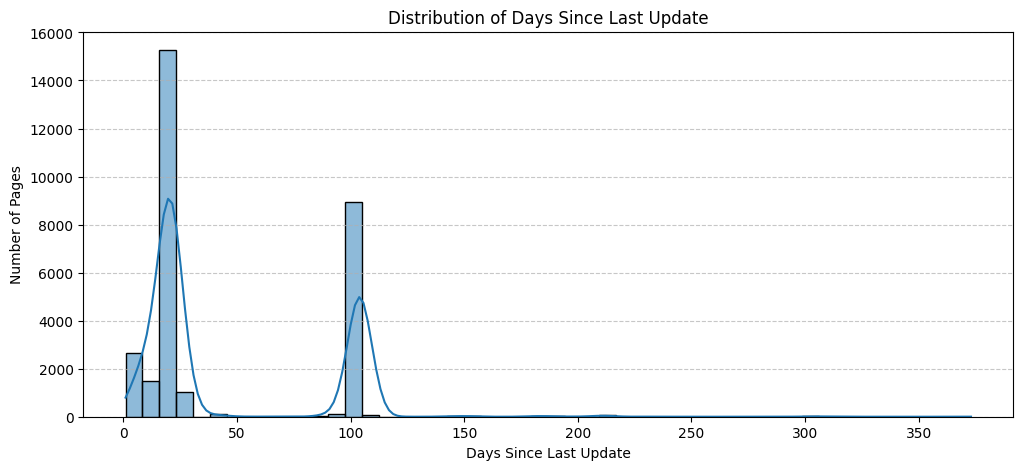

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of content_age_days
plt.figure(figsize=(12, 5))
sns.histplot(df['content_age_days'], bins=50, kde=True)
plt.title('Distribution of Content Age (Days)')
plt.xlabel('Content Age (Days)')
plt.ylabel('Number of Pages')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Distribution of days_since_last_update
plt.figure(figsize=(12, 5))
sns.histplot(df['days_since_last_update'], bins=50, kde=True)
plt.title('Distribution of Days Since Last Update')
plt.xlabel('Days Since Last Update')
plt.ylabel('Number of Pages')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [16]:
#Computing age_tier counts to further check the count of pages
df['age_tier'].value_counts()

,count
age_tier,
91-180,11780
181-365,11368
365+,6360
31-90,492


In [15]:
df['freshness_tier'].value_counts()

,count
freshness_tier,
0-30,20480
91-180,9171
31-90,175
181+,174


#### Interpretation for Unbalanced History:

* So from the above queries we can conclude that relationship between how old the content was and it's number of pages is uneven. Most of the pages fall 91-180 & 181 & 365 age tier and very few fall under 31-90 tier. Same is with the recent update case in which the most pages are updated under 0-30 & 91-180 days tier and very few very updated under 31-90 and 181+ tier.

### Investigating 'GSC-only early rows'

This limit implies that older data points might lack certain information that became available later (e.g., from Google Analytics or internal systems). A way to check this is to see if the proportion of missing values in certain non-GSC-specific columns changes with the `content_age_days`.

Checking missingness for columns: ['provider_used', 'char_count', 'word_count_tier', 'char_count_tier', 'word_count', 'model_used', 'competition_level', 'competition', 'search_volume', 'cpc', 'main_intent']


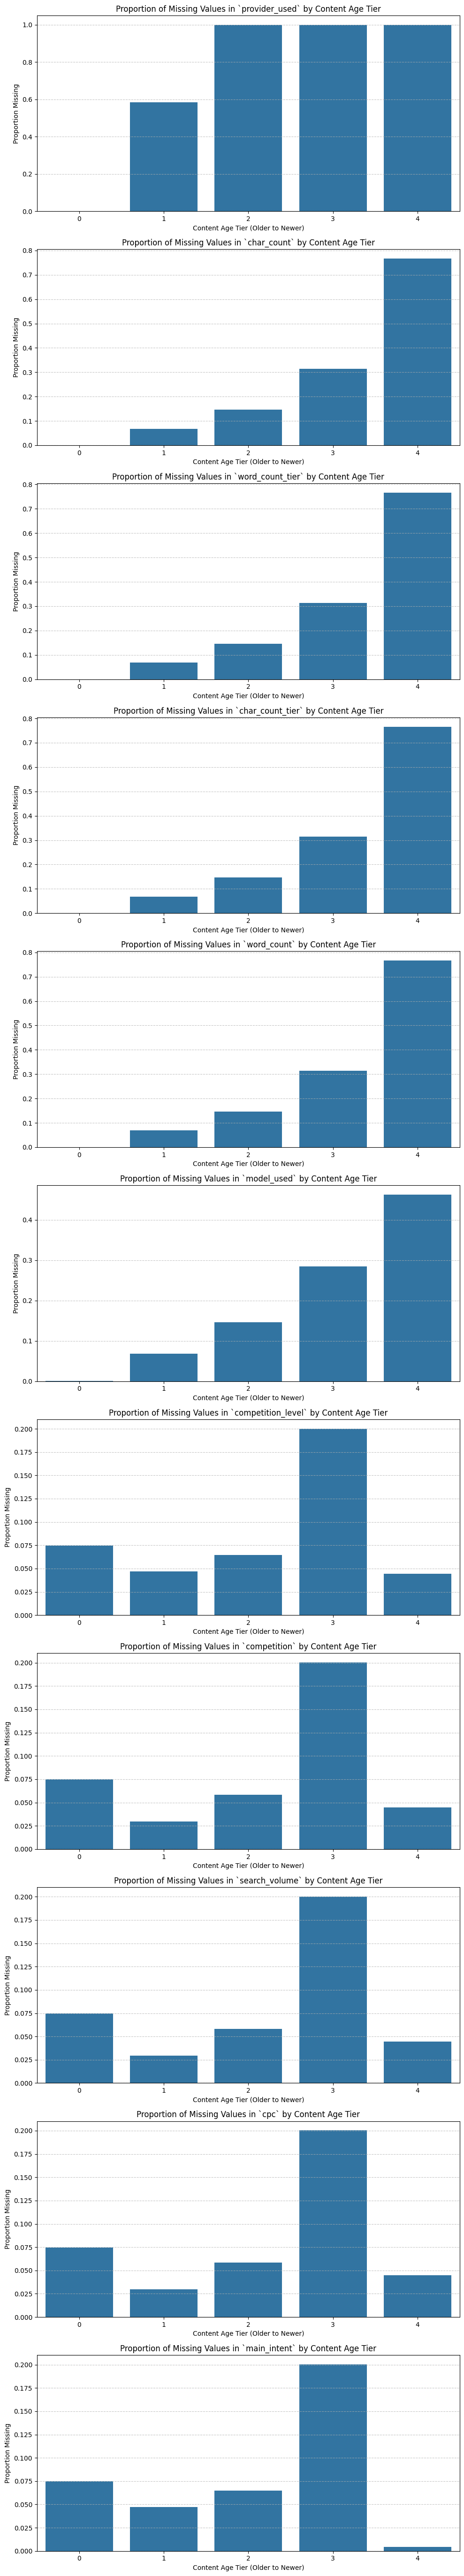

In [18]:
# Identify columns with significant missing values from your feature_columns
columns_to_check_for_missingness = missing_info.index.tolist()

if columns_to_check_for_missingness:
    print(f"Checking missingness for columns: {columns_to_check_for_missingness}")

    # Bin content_age_days to analyze missingness across age groups
    df['content_age_tier'] = pd.qcut(df['content_age_days'], q=5, labels=False, duplicates='drop') # 5 quantiles

    fig, axes = plt.subplots(len(columns_to_check_for_missingness), 1, figsize=(10, 5 * len(columns_to_check_for_missingness)))
    if len(columns_to_check_for_missingness) == 1: # Handle single subplot case
        axes = [axes]

    for i, col in enumerate(columns_to_check_for_missingness):
        missing_by_age_tier = df.groupby('content_age_tier')[col].apply(lambda x: x.isnull().sum() / len(x))
        sns.barplot(x=missing_by_age_tier.index, y=missing_by_age_tier.values, ax=axes[i])
        axes[i].set_title(f'Proportion of Missing Values in `{col}` by Content Age Tier')
        axes[i].set_xlabel('Content Age Tier (Older to Newer)')
        axes[i].set_ylabel('Proportion Missing')
        axes[i].grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    # Drop the temporary content_age_tier column
    df.drop(columns=['content_age_tier'], inplace=True)
else:
    print("No feature columns identified with missing values to check for 'GSC-only early rows' pattern.")

In [19]:
# Verify missing values in the label column to confirm these columns are not needed to investigate GSC only rows
missing_in_label = df[label_column].isnull().sum()

if missing_in_label == 0:
    print(f"Verification successful: The label column '{label_column}' has no missing values.")
else:
    print(f"Warning: The label column '{label_column}' has {missing_in_label} missing values. This should be investigated.")

Verification successful: The label column 'is_high_impressions_low_ctr_tiered' has no missing values.


#### Interpretation for GSC-only early rows:

*   By examining the missing values in non-GSC related feature columns like `provider_used`, `word_count`, `model_used`, and `main_intent` across different content age tiers, we observe varying completeness.
*   For many of these features,3rd content tier shows the highest missingness at ~20%, older content tends to have a higher proportion of missing data.
*  For features like char count, word count tier, char count tier, word_count and model used  the missing values increase from 0-4 content age tier this suggests that these fields are less available for older content. If the affected fields are confirmed to come from systems added after GSC collection began, the result for these features would support the possibility of GSC-only early rows. while for remaining features Missingness varies by column, and no single consistent relationship with content age is visible. Therefore, the missing data may have multiple causes, and the GSC-only early-row explanation cannot be confirmed from this analysis alone.

### Investigating 'Window Overlaps'

'Window overlaps' refers to potential ambiguities or inconsistencies in how different time-windowed metrics (like 90-day impressions vs. last 30-day impressions) are defined or calculated. Ideally, these windows should be distinct and clearly understood.

Following are some codes that check time window overlaps across sessions , clicks and impressions by adding last 60 days impressions/clicks and compare it with last 90 days to see if their sum is greater than 90 days or not.

In [26]:
# Check impressions window consistency

df['impressions_60d_sum'] = (
    df['impressions_last_30d'] +
    df['impressions_prev_30d']
)

df['impressions_window_issue'] = (
    df['impressions_60d_sum'] >
    df['impressions_90d']
)

print("Impression rows with possible window issue:")
print(df['impressions_window_issue'].sum())

Impression rows with possible window issue:
0


In [27]:
df['clicks_60d_sum'] = (
    df['clicks_last_30d'] +
    df['clicks_prev_30d']
)

df['clicks_window_issue'] = (
    df['clicks_60d_sum'] >
    df['clicks_90d']
)

print("Click rows with possible window issue:")
print(df['clicks_window_issue'].sum())

Click rows with possible window issue:
0


In [28]:
df['sessions_60d_sum'] = (
    df['sessions_last_30d'] +
    df['sessions_prev_30d']
)

df['sessions_window_issue'] = (
    df['sessions_60d_sum'] >
    df['sessions_90d']
)

print("Session rows with possible window issue:")
print(df['sessions_window_issue'].sum())

Session rows with possible window issue:
0


In [29]:
#Interpreting all the results together
print("Possible impression issues:",
      df['impressions_window_issue'].sum())

print("Possible click issues:",
      df['clicks_window_issue'].sum())

print("Possible session issues:",
      df['sessions_window_issue'].sum())

Possible impression issues: 0
Possible click issues: 0
Possible session issues: 0


#### Interpretation for Window Overlaps:

The combined last-30-day and previous-30-day values do not exceed their corresponding 90-day values. This is consistent with the windows being separate parts of the 90-day period, but it does not prove that the windows do not overlap. This can only be confirm by knowing the exact start and end date for each window

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.